# 2. YOLO 모델 결과 분석 및 졸음 감지 로직 구현 🕵️‍♀️

지난 시간에 우리가 직접 학습시킨 **YOLO 모델(`best.pt`)**을 불러와서 테스트해볼 시간입니다.
이번 시간에는 모델이 찾아낸 얼굴의 특징점(Keypoints) 번호를 직접 확인하고, 이를 이용해 졸음을 판단하는 코드를 작성해 봅니다.

### 🚀 미션 목표
1. **모델 로드:** 학습된 YOLO 모델 불러오기
2. **번호 확인(Mapping):** 모델이 예측한 점들 중 '눈'은 몇 번 점인지 시각화하여 찾아내기
3. **알고리즘 구현:** 눈의 특징점을 연결하여 EAR(눈 뜸 정도) 계산하기

---

In [15]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance as dist

In [16]:
# 1. 학습된 모델 불러오기
# (01_train.ipynb에서 학습 후 생성된 weights/best.pt 파일 경로를 지정하세요)
model_path = '../runs/pose/train6/weights/best.pt' 

try:
    model = YOLO(model_path)
    print("✅ 모델 로드 성공! 이제 예측을 시작할 수 있습니다.")
except:
    print("❌ 모델 파일을 찾을 수 없습니다. 경로를 확인해주세요!")

✅ 모델 로드 성공! 이제 예측을 시작할 수 있습니다.


---
## 1단계: 내 모델은 눈을 몇 번 점으로 생각할까? 🤔

우리가 학습시킨 모델이 얼굴의 점을 0번부터 순서대로 찾습니다.
하지만 몇 번 점이 '왼쪽 눈꼬리'인지, '오른쪽 눈꺼풀'인지 우리는 아직 모릅니다.

아래 코드를 실행해서 **얼굴 위에 그려진 번호**를 보고, 눈에 해당하는 번호를 직접 찾아보세요!


image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/test/images/26638112_1.jpg: 640x448 1 face, 11.0ms
Speed: 2.8ms preprocess, 11.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)


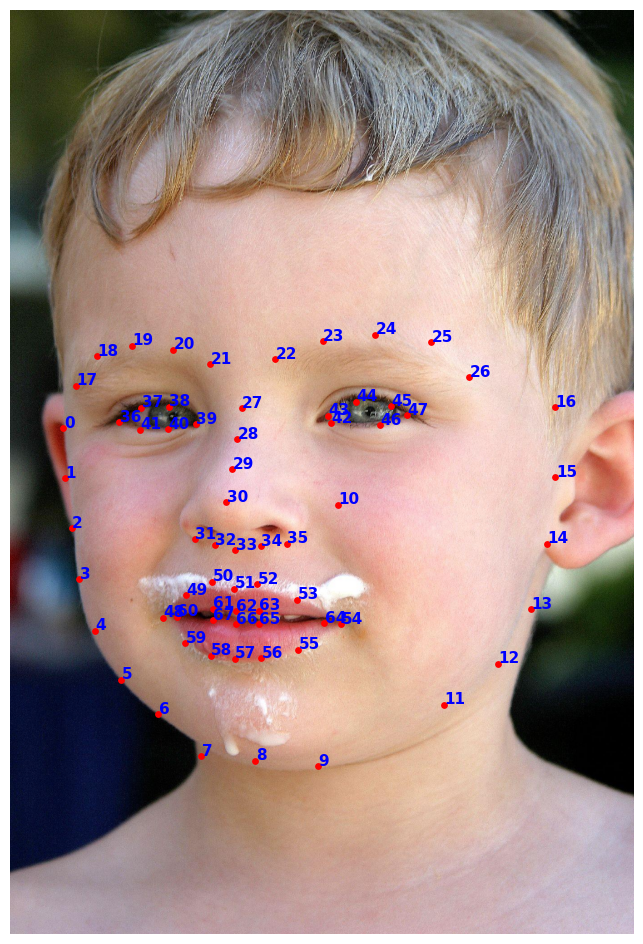

In [17]:
import cv2
import matplotlib.pyplot as plt

def show_keypoint_indices(model, image_path, selected_points = []):
    # 1. 예측 및 이미지 로드
    results = model(image_path)
    points = results[0].keypoints.xy[0].cpu().numpy()
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # 2. 시각화 (이미지 크기를 키워 번호가 잘 보이게 설정)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    
    # 3. 점과 번호 찍기
    for i, (x, y) in enumerate(points):
        if x == 0 and y == 0: continue # 미검출 제외
        if selected_points != [] and i not in selected_points:
            continue  # 선택된 점이 있을 경우, 그 점들만 표시
        plt.scatter(x, y, s=15, c='red') # 빨간 점
        # 번호가 잘 보이도록 약간의 오프셋과 굵은 글씨 적용
        plt.text(x+1, y-1, str(i), fontsize=11, color='blue', weight='bold')

    plt.axis('off')
    plt.show()

# 사용 예시
show_keypoint_indices(model, '../data/test/images/26638112_1.jpg')

---

## 2단계: 눈 좌표 설정하기 👁️📝

위 그림을 자세히 확대해서 보세요.

**오른쪽 눈**을 감싸고 있는 점 6개의 번호와, **왼쪽 눈**을 감싸고 있는 점 6개의 번호를 순서대로 적어주세요.

(보통 시계 방향 혹은 반시계 방향으로 이어져 있습니다.)

In [6]:
# --- [학생 미션 1] 그림을 보고 번호를 채워넣으세요 ---

# 예시: RIGHT_EYE_IDXS = [36, 37, 38, 39, 40, 41] 
# (주의: 여러분의 모델 결과에 따라 번호가 다를 수 있습니다!)

# TODO: 오른쪽 눈 점 6개 번호 리스트 (36~41번)
RIGHT_EYE_IDXS = [36, 37, 38, 39, 40, 41]

# TODO: 왼쪽 눈 점 6개 번호 리스트 (42~47번)
LEFT_EYE_IDXS = [42, 43, 44, 45, 46, 47]

print(f"설정된 오른쪽 눈 번호: {RIGHT_EYE_IDXS}")
print(f"설정된 왼쪽 눈 번호: {LEFT_EYE_IDXS}")

설정된 오른쪽 눈 번호: [36, 37, 38, 39, 40, 41]
설정된 왼쪽 눈 번호: [42, 43, 44, 45, 46, 47]



image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/test/images/26638112_1.jpg: 640x448 1 face, 17.2ms
Speed: 5.9ms preprocess, 17.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 448)


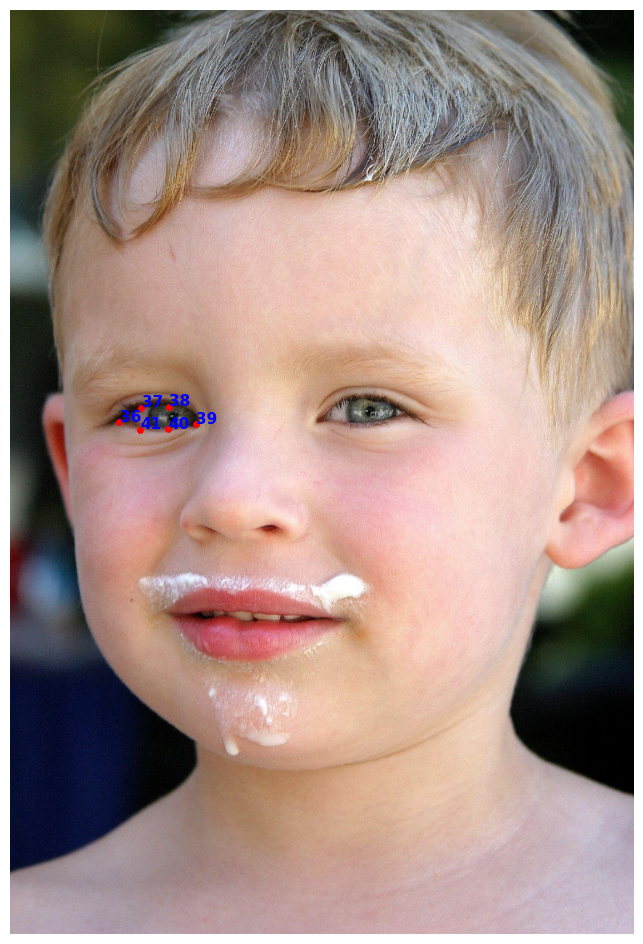


image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/test/images/26638112_1.jpg: 640x448 1 face, 9.4ms
Speed: 2.4ms preprocess, 9.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)


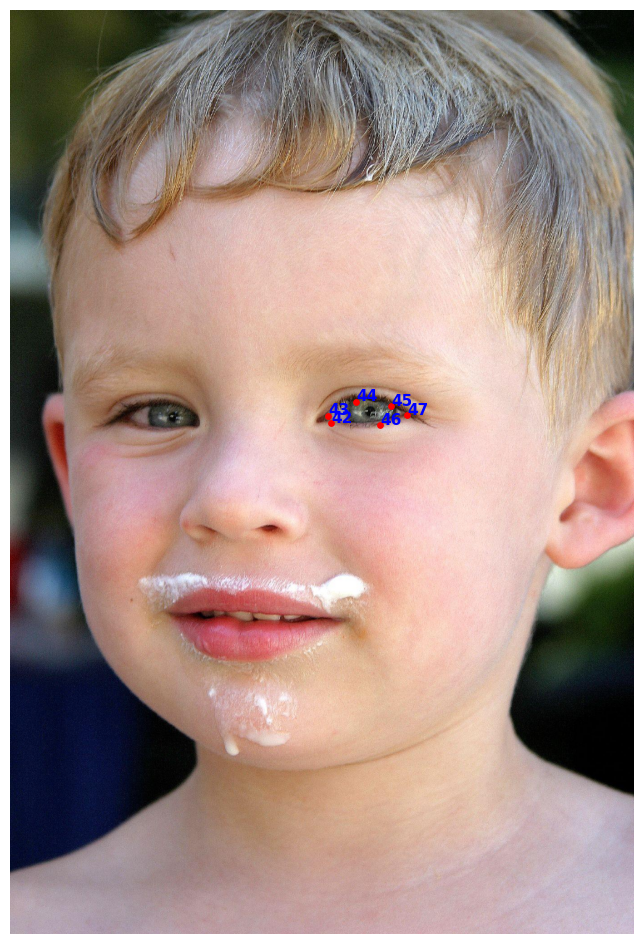

In [7]:
# 확인
show_keypoint_indices(model, '../data/test/images/26638112_1.jpg', selected_points=RIGHT_EYE_IDXS)
show_keypoint_indices(model, '../data/test/images/26638112_1.jpg', selected_points=LEFT_EYE_IDXS)

---
## 3단계: 졸음 판단 공식 (EAR) 구현하기 📐

이제 선택한 점들을 이용해서 **눈이 얼마나 떠졌는지(EAR)** 계산하는 함수를 만듭니다.

$$EAR = \frac{(p2와 p6 거리) + (p3와 p5 거리)}{2 \times (p1과 p4 거리)}$$

여기서 `p1`~`p6`는 여러분이 위에서 선택한 6개의 점을 순서대로 의미합니다.
* `p1`, `p4`: 눈의 양 끝점 (가로)
* `p2`, `p6`: 눈의 위아래 (세로 1)
* `p3`, `p5`: 눈의 위아래 (세로 2)

In [8]:
from scipy.spatial import distance as dist

def calculate_ear(keypoints, indices):
    """
    전체 키포인트와 눈의 인덱스 리스트를 받아서 EAR을 계산하는 함수
    """
    # 해당 인덱스의 좌표만 추출
    eye_pts = keypoints[indices]
    
    # 좌표가 6개가 아니면 계산 불가
    if len(eye_pts) != 6:
        return 0
    
    # p1 ~ p6 좌표 정의 (리스트 순서대로 0~5번 인덱스)
    # p1: 눈 바깥쪽 끝, p4: 눈 안쪽 끝
    # p2, p3: 위쪽 눈꺼풀 / p6, p5: 아래쪽 눈꺼풀
    p1 = eye_pts[0]
    p2 = eye_pts[1]
    p3 = eye_pts[2]
    p4 = eye_pts[3]
    p5 = eye_pts[4]
    p6 = eye_pts[5]
    
    # --- [학생 미션 2] 유클리드 거리 계산 코드 작성 ---
    
    # 1. 눈의 세로 길이 (A, B)
    # p2와 p6 사이의 거리 (첫 번째 세로)
    vertical_1 = dist.euclidean(p2, p6)
    # TODO: p3와 p5 사이의 거리 (두 번째 세로)
    vertical_2 = dist.euclidean(p3, p5)
    
    # 2. 눈의 가로 길이 (C)
    # TODO: p1과 p4 사이의 거리 (가로)
    horizontal = dist.euclidean(p1, p4)

    # 3. EAR 계산
    # TODO: 수식 완성 -> (세로1 + 세로2) / (2.0 * 가로)
    # 가로 길이가 0일 경우(나눗셈 에러)를 방지하기 위한 안전장치 추가를 권장하지만, 
    # 학생용 코드이므로 기본 수식에 집중합니다.
    ear = (vertical_1 + vertical_2) / (2.0 * horizontal)
    
    return ear

---
## 4단계: 최종 결과 확인 🧪

이제 `open.png`와 `close.png`를 넣었을 때, 우리가 만든 모델과 알고리즘이 졸음을 잘 구분하는지 확인해 봅시다.

=== 뜬 눈 테스트 ===

image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/demo/iu_open.png: 384x640 1 face, 9.9ms
Speed: 1.7ms preprocess, 9.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


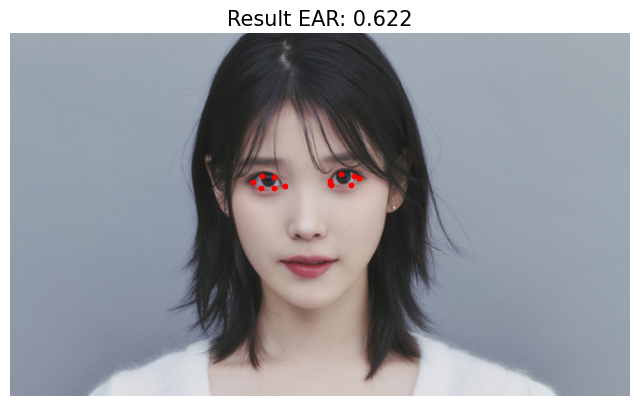


=== 감은 눈 테스트 ===

image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/demo/iu_close.png: 352x640 1 face, 10.1ms
Speed: 1.8ms preprocess, 10.1ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)


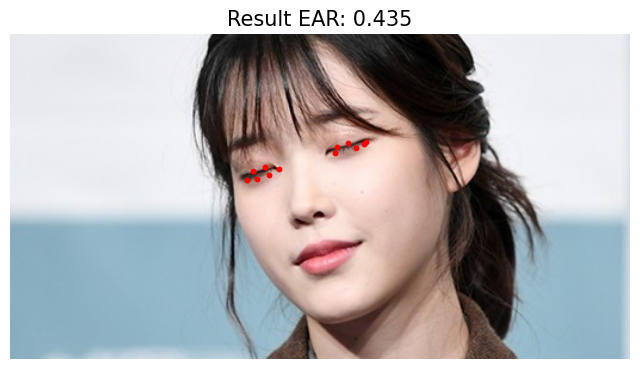


[결과 분석] 뜬 눈(0.622) vs 감은 눈(0.435)
✅ 성공! 뜬 눈의 EAR 값이 더 큽니다.


In [11]:
def test_drowsiness(image_path, model):
    results = model(image_path)
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # 위에서 만든 함수로 EAR 계산
    right_ear = calculate_ear(keypoints, RIGHT_EYE_IDXS)
    left_ear = calculate_ear(keypoints, LEFT_EYE_IDXS)
    
    # 양쪽 눈의 평균 사용
    avg_ear = (right_ear + left_ear) / 2.0
    
    # 시각화
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Result EAR: {avg_ear:.3f}", fontsize=15)
    
    # 눈 위치에 점 찍기 (확인용)
    for idx in RIGHT_EYE_IDXS + LEFT_EYE_IDXS:
        pt = keypoints[idx]
        plt.scatter(pt[0], pt[1], c='red', s=10)
        
    plt.axis('off')
    plt.show()
    
    return avg_ear

# 테스트 실행
print("=== 뜬 눈 테스트 ===")
ear_open = test_drowsiness('../data/demo/iu_open.png', model)

print("\n=== 감은 눈 테스트 ===")
ear_close = test_drowsiness('../data/demo/iu_close.png', model)

print(f"\n[결과 분석] 뜬 눈({ear_open:.3f}) vs 감은 눈({ear_close:.3f})")
if ear_open > ear_close:
    print("✅ 성공! 뜬 눈의 EAR 값이 더 큽니다.")
else:
    print("❌ 실패! 인덱스 순서나 코드를 다시 확인해보세요.")

=== 뜬 눈 테스트 (시각화 업그레이드) ===

image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/demo/iu_open.png: 384x640 1 face, 14.8ms
Speed: 2.6ms preprocess, 14.8ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


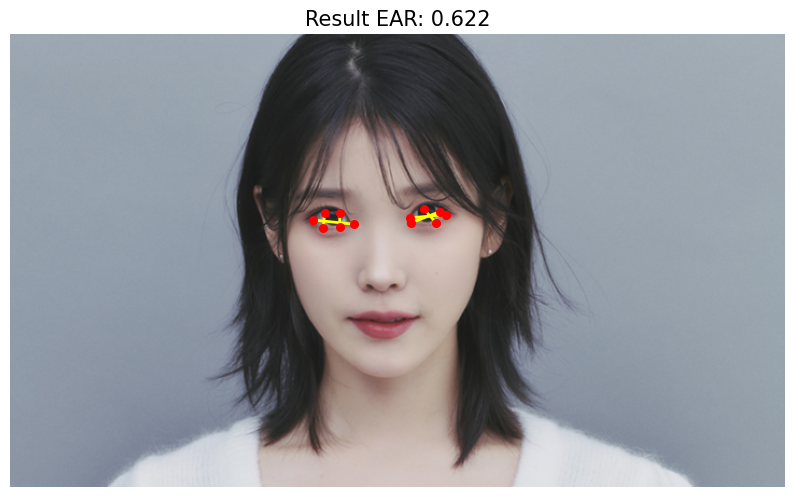


=== 감은 눈 테스트 ===

image 1/1 /home/nute11a/workspace/2026_AI_Advanced_Study/4차시/01_facial_detection/code/../data/demo/iu_close.png: 352x640 1 face, 9.8ms
Speed: 1.8ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)


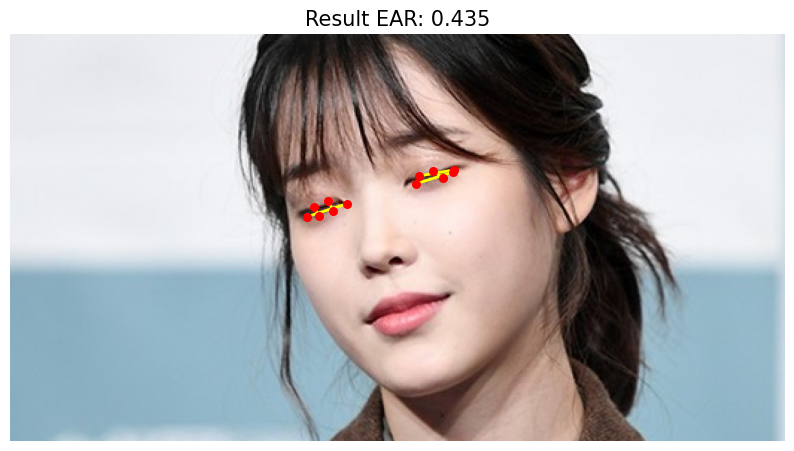

In [14]:
def test_drowsiness_visualized(image_path, model):
    results = model(image_path)
    # 키포인트 좌표 가져오기
    keypoints = results[0].keypoints.xy[0].cpu().numpy()
    
    # EAR 계산
    right_ear = calculate_ear(keypoints, RIGHT_EYE_IDXS)
    left_ear = calculate_ear(keypoints, LEFT_EYE_IDXS)
    
    # 양쪽 눈의 평균 사용
    avg_ear = (right_ear + left_ear) / 2.0
    
    # 이미지 준비
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title(f"Result EAR: {avg_ear:.3f}", fontsize=15)
    
    # --- [시각화 업그레이드] 선 그리기 ---
    # 오른쪽 눈, 왼쪽 눈 각각 반복
    for eye_idxs in [RIGHT_EYE_IDXS, LEFT_EYE_IDXS]:
        # 현재 눈의 6개 점 좌표만 가져옴 (순서대로 0~5번 인덱스가 됨)
        # 0:왼쪽끝, 1:위1, 2:위2, 3:오른쪽끝, 4:아래2, 5:아래1
        eye_points = keypoints[eye_idxs]
        
        # 1. 점 찍기 (빨간색)
        # eye_points[:, 0]은 x좌표들, eye_points[:, 1]은 y좌표들
        plt.scatter(eye_points[:, 0], eye_points[:, 1], c='red', s=30, zorder=3)
        
        # 2. 선 그리기 (노란색, EAR 공식에 쓰이는 선들)
        # 세로 선 1 (p2 <-> p6) : 인덱스 1번과 5번 연결
        plt.plot([eye_points[1,0], eye_points[5,0]], 
                 [eye_points[1,1], eye_points[5,1]], 
                 color='yellow', linewidth=2)
        
        # 세로 선 2 (p3 <-> p5) : 인덱스 2번과 4번 연결
        plt.plot([eye_points[2,0], eye_points[4,0]], 
                 [eye_points[2,1], eye_points[4,1]], 
                 color='yellow', linewidth=2)
                 
        # 가로 선 (p1 <-> p4) : 인덱스 0번과 3번 연결
        plt.plot([eye_points[0,0], eye_points[3,0]], 
                 [eye_points[0,1], eye_points[3,1]], 
                 color='yellow', linewidth=2)

    plt.axis('off')
    plt.show()
    
    return avg_ear

# 테스트 실행
print("=== 뜬 눈 테스트 (시각화 업그레이드) ===")
ear_open = test_drowsiness_visualized('../data/demo/iu_open.png', model)

print("\n=== 감은 눈 테스트 ===")
ear_close = test_drowsiness_visualized('../data/demo/iu_close.png', model)